In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
#Load the space-separated file
df = pd.read_csv("cal_housing.data", header=None, sep=",")

In [59]:
#Get the columns from the file
df.columns = [
    "longitude", 
    "latitude", 
    "housingMedianAge", 
    "totalRooms", 
    "totalBedrooms", 
    "population", 
    "households", 
    "medianIncome", 
    "medianHouseValue"
]

In [60]:
df.head()

,longitude,latitude,housingMedianAge,totalRooms,totalBedrooms,population,households,medianIncome,medianHouseValue
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0


In [61]:
df.dtypes

longitude           float64
latitude            float64
housingMedianAge    float64
totalRooms          float64
totalBedrooms       float64
population          float64
households          float64
medianIncome        float64
medianHouseValue    float64
dtype: object

In [62]:
# Print the unique values and the number of non-unique values
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

longitude
[-122.23 -122.22 -122.24 -122.25 -122.26]
844

latitude
[37.88 37.86 37.85 37.84 37.83]
862

housingMedianAge
[41. 21. 52. 42. 50.]
52

totalRooms
[ 880. 7099. 1467. 1274. 1627.]
5926

totalBedrooms
[ 129. 1106.  190.  235.  280.]
1928

population
[ 322. 2401.  496.  558.  565.]
3888

households
[ 126. 1138.  177.  219.  259.]
1815

medianIncome
[8.3252 8.3014 7.2574 5.6431 3.8462]
12928

medianHouseValue
[452600. 358500. 352100. 341300. 342200.]
3842



<Axes: xlabel='medianHouseValue', ylabel='Count'>

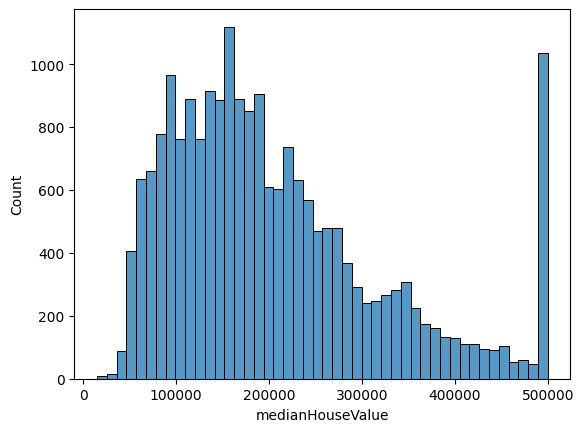

In [63]:
# medianHouseValue is the target variable, so that’s the housing price to predict
sns.histplot(df.medianHouseValue)

In [64]:
df.shape[0]

20640

#### medianHouseValue has a right tail since most homes are affordable, but a few extremely expensive ones pull the distribution far to the right.

In [65]:
# log1p compresses large values i.e (shrinks the tail)
# Keeps the scale of small values relatively intact
# Helps make the distribution more normal-shaped (Gaussian)

house_value_logs = np.log1p(df.medianHouseValue)

In [66]:
house_value_logs

0        13.022766
1        12.789687
2        12.771673
3        12.740520
4        12.743154
           ...    
20635    11.265758
20636    11.252872
20637    11.432810
20638    11.346883
20639    11.400887
Name: medianHouseValue, Length: 20640, dtype: float64

<Axes: xlabel='medianHouseValue', ylabel='Count'>

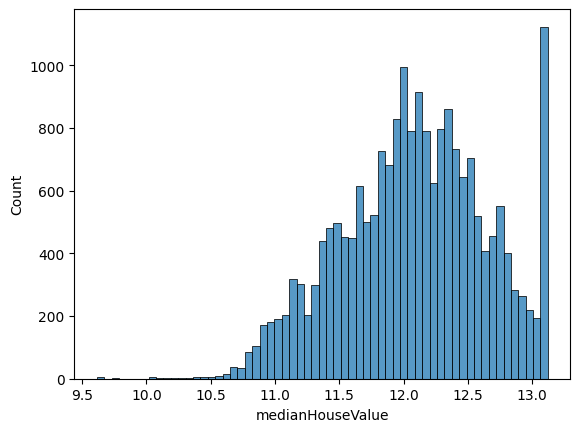

In [67]:
sns.histplot(house_value_logs)

In [68]:
# Values above $500,001 were censored, which may bias predictions for high-value homes.
df_capped = (df["medianHouseValue"] > 500000).sum()

In [69]:
df_capped

np.int64(965)

# Setting up the validation framework

In [70]:
np.random.seed(2)

n = len(df)

# split dataset where 20% is the validation and test data, while 60% is the train data
n_val = int(0.2 * n) 
n_test = int(0.2 * n)
n_train = n - (n_val + n_test)

In [71]:
n_val, n_test, n_train

(4128, 4128, 12384)

In [72]:
# We need to shuffle the dataset before splitting, so we don't have the split in a sequential order
idx = np.arange(n)
np.random.shuffle(idx)
print('idx here', idx)
df_shuffled = df.iloc[idx]

idx here [10385  1943  7490 ... 11798  6637  2575]


In [73]:
# Here we split, we use the copy() so we can still keep the original dataset
df_train = df_shuffled.iloc[:n_train].copy()
df_val = df_shuffled.iloc[n_train:n_train+n_val].copy()
df_test = df_shuffled.iloc[n_train+n_val:].copy()

In [74]:
# We reset the index in a sequential order
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [75]:
df_train.head()

,longitude,latitude,housingMedianAge,totalRooms,totalBedrooms,population,households,medianIncome,medianHouseValue
0,-117.65,33.60,15.0,5736.0,800.0,2529.0,762.0,6.4114,278700.0
1,-120.91,38.62,12.0,4545.0,748.0,2033.0,718.0,4.1843,207600.0
2,-118.23,33.93,35.0,1149.0,277.0,909.0,214.0,1.7411,96700.0
3,-122.37,37.59,39.0,4645.0,1196.0,2156.0,1113.0,3.4412,353800.0
4,-117.98,33.70,16.0,5127.0,631.0,2142.0,596.0,7.8195,390500.0


In [76]:
# To reduce skewness and stabilize variance, log1p is applied, making the regression model perform better.
y_train = np.log1p(df_train['medianHouseValue'].values)
y_val = np.log1p(df_val['medianHouseValue'].values)
y_test = np.log1p(df_test['medianHouseValue'].values)

In [77]:
del df_train['medianHouseValue']
del df_val['medianHouseValue']
del df_test['medianHouseValue']

In [78]:
df_train.head()

,longitude,latitude,housingMedianAge,totalRooms,totalBedrooms,population,households,medianIncome
0,-117.65,33.60,15.0,5736.0,800.0,2529.0,762.0,6.4114
1,-120.91,38.62,12.0,4545.0,748.0,2033.0,718.0,4.1843
2,-118.23,33.93,35.0,1149.0,277.0,909.0,214.0,1.7411
3,-122.37,37.59,39.0,4645.0,1196.0,2156.0,1113.0,3.4412
4,-117.98,33.70,16.0,5127.0,631.0,2142.0,596.0,7.8195


In [79]:
len(y_train)

12384

# Linear regression

In [80]:
df_train.iloc[10] # Show me the 11th row of the df_train

longitude           -117.9900
latitude              33.6600
housingMedianAge      14.0000
totalRooms          3155.0000
totalBedrooms        653.0000
population           951.0000
households           575.0000
medianIncome           3.0625
Name: 10, dtype: float64

In [81]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]